## Канонический ансамбль

- Работаем в терминах система ($E_s$) + термостат ($E_b$) (термостат >> система). Количество частиц в каждой из подсистем постоянно. Термостат намного больше системы.

- $E_s + E_b = const$

- Хотим найти вероятность того, что система находится в состоянии $s$:

$$
P_s=\frac{\Omega(E_s)\cdot \Omega(E-E_s)}{\sum_s \Omega(E_s)\cdot \Omega(E-E_s)}
$$

После логарифмирования, пренебрежения $ln \Omega(E_s)$ и приближения $ E_s << E$, имеем каноническое распределение

$$
P_s = const \cdot e^{-\frac{E_s}{T}} = \frac{1}{Z}\cdot e^{-\frac{E_s}{T}}
$$

где

$$
\beta = \frac{1}{T} = \frac{\partial \Omega(E_s)}{\partial E_b}
$$

- Отсюда и стат. сумма и проч.

$$
Z = \sum_s e^{-\beta E_s}
$$

$$
<E> = \sum_s P_s E_s = \frac{1}{Z} \sum_s E_s e^{-\beta E_s}
$$

$$
C_V = \frac{1}{T^2}(<E^2> - <E>^2)
$$

$$
F = -T ln Z
$$

- Стат. сумму можно получить только для идеального газа. В остальных случаях не считается.

- Для того чтобы выйти за "идеальность" в уравнениях состояния используют вириальное разложение (но и оно не очень хорошо - сходится только для газов).

- А вот моделирование даёт ответ!

## Генерация неравномерно распределённых случайных чисел

- Пусть $\gamma$ - случайное число, равномерно распределённое на отрезке [0, 1]. Хотим из неё получить произвольное распределение $p(x)$.

- Определим интегральную функцию распределения $P(x) = \int_{-\infty}^{x} p(x') dx'$

Тогда необходимо просто решить уравнение $ P(x) = \gamma$ относительно $x$:

$$
x=P^{-1}(\gamma)
$$

Действительно, имеем нужную плотность распределения

$$
dP(x) =P'(x)dx=p(x)dx=d\gamma
$$

- Крайне сложно находить обратные интегральные операторы, особенно в многомерии.

### Алгоритм генерации произвольного распределения случайной величины (алгоритм Метрополиса)

- Алгоритм основан на цепи Маркова - последовательность состояний {$x_i$} с вероятностями перехода $w(x_i \rightarrow x_j)$

Пусть выполнен принцип детального баланса (т.е. имеем равновесное распределение): $p(x_i)w(x_i \rightarrow x_j)=p(x_j)w(x_j \rightarrow x_i)$

Надо выбрать функцию перехода, удовлетворющую уравнению баланса. Выберем следующую

$$
w(x_i \rightarrow x_j)=min\left(1, \frac{x_j}{x_i}\right)
$$

Итого, сам алгоритм Метрополиса:

1. Выбираем начальное значение $x$

2. Генерируем следующее значение $x'$, зависящее от $x$. Правило генерации: $x'=x+\text{UNIFORM}(-B, B)$. От $B$ толком ничего не зависит на бесконечности, оптимальное $B$ такое, чтобы примерно половина $x'$ принималась - т.е. это подбираемый параметр.

3. Если $\frac{p(x')}{p(x)} \geq 1$, то принимаем $x'$

3. 1.  Иначе генерируем $\xi \in (0, 1)$, 
   
   2. Если $\xi < \frac{p(x')}{p(x)}$, то принимаем $x'$
   
   3. Иначе оставляем старый $x$
   
4. Повторяем с п.2

### Распределение Гаусса

$x_0 = 0$

$B = 0.1$

0.13867


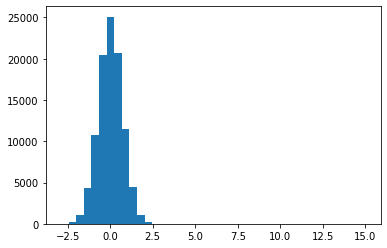

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def proba_density(x):
    
    return np.exp(-x**2)

x = 15
B = 0.5

N = 100000

xs = np.zeros(N)
xs[0] = x

rejected = 0
for i in range(1, N):
    x_cand = xs[i-1] + np.random.uniform(-B, B)
    
    if proba_density(x_cand)/proba_density(xs[i-1]) >= 1:
        xs[i] = x_cand
        continue
    else:
        if np.random.uniform(0, 1) < proba_density(x_cand)/proba_density(xs[i-1]):
            xs[i] = x_cand
            continue
        else:
            xs[i] = xs[i-1]
            rejected += 1
            continue
plt.hist(xs, bins = 40)
print(rejected/N)

249


(array([5.000e+00, 7.000e+00, 1.300e+01, 3.700e+01, 5.700e+01, 8.400e+01,
        1.710e+02, 2.970e+02, 4.930e+02, 8.860e+02, 1.229e+03, 1.739e+03,
        2.411e+03, 3.146e+03, 4.229e+03, 5.263e+03, 6.305e+03, 7.220e+03,
        7.940e+03, 8.282e+03, 8.259e+03, 7.766e+03, 7.230e+03, 6.440e+03,
        5.268e+03, 4.204e+03, 3.417e+03, 2.506e+03, 1.680e+03, 1.218e+03,
        7.930e+02, 4.830e+02, 3.090e+02, 1.710e+02, 1.000e+02, 5.600e+01,
        1.000e+01, 1.500e+01, 2.000e+00, 1.000e+01]),
 array([-2.89836468, -2.75252128, -2.60667788, -2.46083447, -2.31499107,
        -2.16914767, -2.02330427, -1.87746087, -1.73161747, -1.58577407,
        -1.43993067, -1.29408726, -1.14824386, -1.00240046, -0.85655706,
        -0.71071366, -0.56487026, -0.41902686, -0.27318346, -0.12734005,
         0.01850335,  0.16434675,  0.31019015,  0.45603355,  0.60187695,
         0.74772035,  0.89356375,  1.03940716,  1.18525056,  1.33109396,
         1.47693736,  1.62278076,  1.76862416,  1.91446756,  2.0

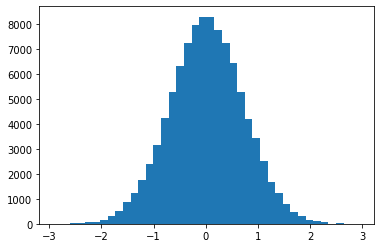

In [2]:
eps = 0.5*1e-2
i_cut = -1
for i, x in enumerate(xs):
    if np.abs(x) < eps:
        print(i)
        i_cut = i
        break
        
plt.hist(xs[i_cut:], bins = 40)

### Изинг (2d)

- Решётка взаимодействующих спинов. NxN c ПГУ

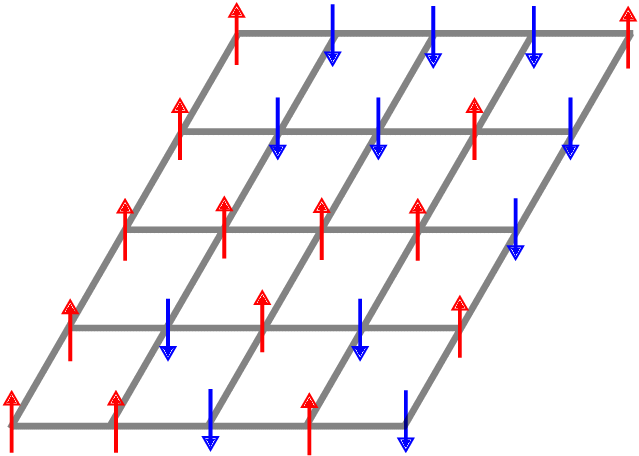

In [3]:
from numba import njit, prange

@njit()
def E_calc(system: np.array, N: int) -> float:
    
    E = 0
    
    for i in range(N):
        for j in range(N):
            
            if (i != 0) and (j != 0):
                E -= (system[i-1, j]*system[i, j] + system[i, j]*system[i, j-1])
                continue
            if (i == 0) and (j != 0):
                E -= (system[N-1, j]*system[i, j] + system[i, j]*system[i, j-1])
                continue
            if (i != 0) and (j == 0):
                E -= (system[i-1, j]*system[i, j] + system[i, j]*system[i, N-1])
                continue
            
    return E

@njit()
def izing(N: int,T: float, steps=5000000):
    
    system = np.ones((N, N))
    
    E = E_calc(system, N)
    
    for i in range(steps):
        
        i1 = np.random.randint(0, N)
        i2 = np.random.randint(0, N)
        
        i_up = i1 - 1
        i_down = i1 + 1
        i_left = i2 - 1
        i_right = i2 + 1
        
        if i_up == -1:
            i_up = N-1
        
        if i_down == N:
            i_down = 0
        
        if i_left == -1:
            i_left = N-1
            
        if i_right == N:
            i_right = 0
        
        deltaE = 2*system[i1, i2]*(system[i_up, i2] + system[i_down, i2] + system[i1, i_left] + system[i1, i_right])
            
        if deltaE < 0:
            system[i1, i2] *= -1
            E += deltaE
        else:
            if np.random.uniform(0,1)<np.exp(-deltaE/T):
                system[i1, i2] *= -1
                E += deltaE
                
    return E, system.mean()



100%|████████████████████████████████████████| 50/50 [-3:02:34<00:00, -0.00it/s]


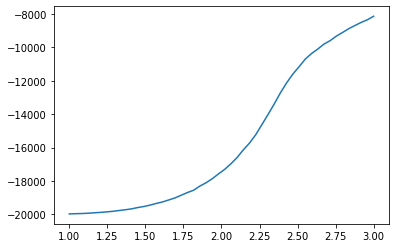

In [4]:
from tqdm import tqdm

N = 100
T = 10

Ms = []
Es = []
Ts = np.linspace(1, 3, 50)

#avg E from T
for T in tqdm(Ts):
    
    E, M = 0, 0
    for i in range(100):
        deltaE, deltaM = izing(N,T, steps=1000000)
        E += deltaE
        M += deltaM
    E /= 100
    M /= 100
    
    Es.append(E)
    Ms.append(M)
    
plt.plot(Ts, Es)

In [54]:
from scipy.optimize import fsolve
from scipy.special import ellipk
from scipy.special import ellipe

def T_crit(T_cand):
    return np.sinh(2/T_cand) - 1
T_c_theory = fsolve(T_crit, 2)[0]

def E_ud_theory(T):
    
    kappa = 2*np.sinh(2./T)/(np.cosh(2./T)**2)
    E = 0
    E += -2*np.tanh(2./T)
    E += -(np.sinh(2./T)**2 - 1)/np.sinh(2./T)/np.cosh(2./T)*(2./np.pi*ellipk(kappa**2) - 1)

    return E

def C_theory(T):
    
    kappa = 2*np.sinh(2./T)/(np.cosh(2./T)**2)
    
    C = 4./np.pi
    
    C *= (1./T/np.tanh(2./T))**2
    
    C *= (ellipk(kappa**2) - ellipe(kappa**2) - (1 - np.tanh(2./T)**2)*(np.pi/2 + (2*np.tanh(2./T)**2 - 1)*ellipk(kappa**2)))
    return C


Text(0.5, 1.0, 'E_уд(T)')

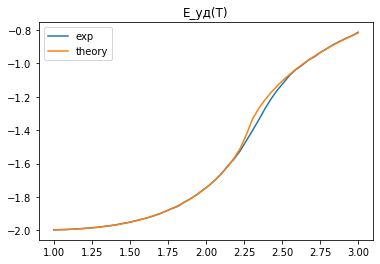

In [37]:
Es = np.array(Es)

Es_theory = E_ud_theory(Ts)

plt.plot(Ts, Es/N**2, label = "exp")
plt.plot(Ts, Es_theory, label = "theory")
plt.legend()
plt.title("E_уд(T)")

Text(0.5, 1.0, 'M(T)')

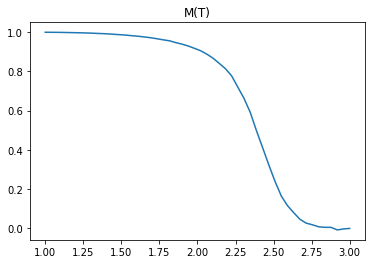

In [6]:
plt.plot(Ts, Ms)
plt.title("M(T)")

Tc_exp = 2.3061224489795915
Tc_theory = 2.269185314213022


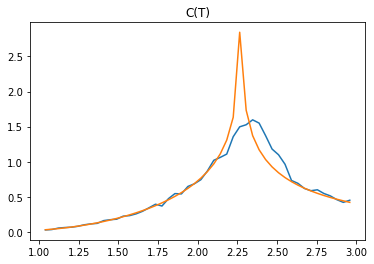

In [55]:
dT = Ts[1] - Ts[0]
Cvs = (Es[2:]-Es[0:-2])/2/dT/N**2

plt.plot(Ts[1:-1], Cvs)
plt.plot(Ts[1:-1], C_theory(Ts[1:-1]))
plt.title("C(T)")
print(f"Tc_exp = {Ts[Cvs.argmax()]}")
print(f"Tc_theory = {T_c_theory}")